# Weight Estimation - YOLO-based Preprocessing

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we explore an alternative preprocessing strategy based on object detection to improve the robustness of the weight estimation model.

Previous experiments showed that segmentation-based approaches (e.g., SAM) are not sufficiently reliable for this task, as they introduce noise and may remove useful contextual information. This motivates the exploration of detection-based methods, which aim to localize the region of interest without altering the visual structure of the image.

To this end, we use a pretrained object detection model (YOLO) to identify the chicken in each image and extract a bounding box around it. The cropped region is then used as input to the regression model.

This approach seeks to normalize spatial variability across images while preserving relevant contextual cues. In addition, a fallback mechanism is introduced: if the detector fails to identify the object, the original image is used instead. This ensures robustness and prevents degradation due to incorrect detections.

All results will be compared against the baseline model to assess whether object detection-based preprocessing provides a consistent improvement in performance.

## 1. Dataset

https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

In this section, we load and prepare the dataset following the same procedure as in previous experiments to ensure consistency and fair comparison.

The key difference in this notebook is that images will later be preprocessed using an object detection model (YOLO) to extract a region of interest before being fed into the regression model.

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path
import random

In [2]:
ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [3]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

**Important**: The image paths in the CSV are relative (e.g., "images/img_00042.jpg").
We convert them to absolute paths so that the dataset can correctly load images from disk.

In [4]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [5]:
dataset = dataset.cast_column("image", Image())

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


Weight: 1243


(np.float64(-0.5), np.float64(1839.5), np.float64(4079.5), np.float64(-0.5))

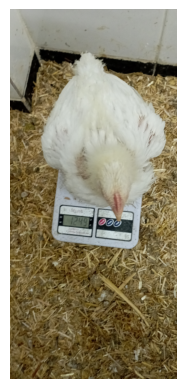

In [7]:
sample = dataset["train"][42]

print("Weight:", sample["weight"])

plt.imshow(sample["image"])
plt.axis("off")

### YOLO

In [8]:
from ultralytics import YOLO
import numpy as np
import cv2
from PIL import Image

YOLO_PATH = ROOT / "models" / "yolo" / "yolov8s.pt"

yolo = YOLO(YOLO_PATH)

print("YOLO loaded from local path")

YOLO loaded from local path


In [9]:
def yolo_crop(img_np, yolo_model):
    results = yolo_model(img_np, verbose=False)

    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        box = boxes.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, box)

        # Safe crop (avoid empty regions)
        if x2 > x1 and y2 > y1:
            return img_np[y1:y2, x1:x2]

    # Fallback → return original image
    return img_np

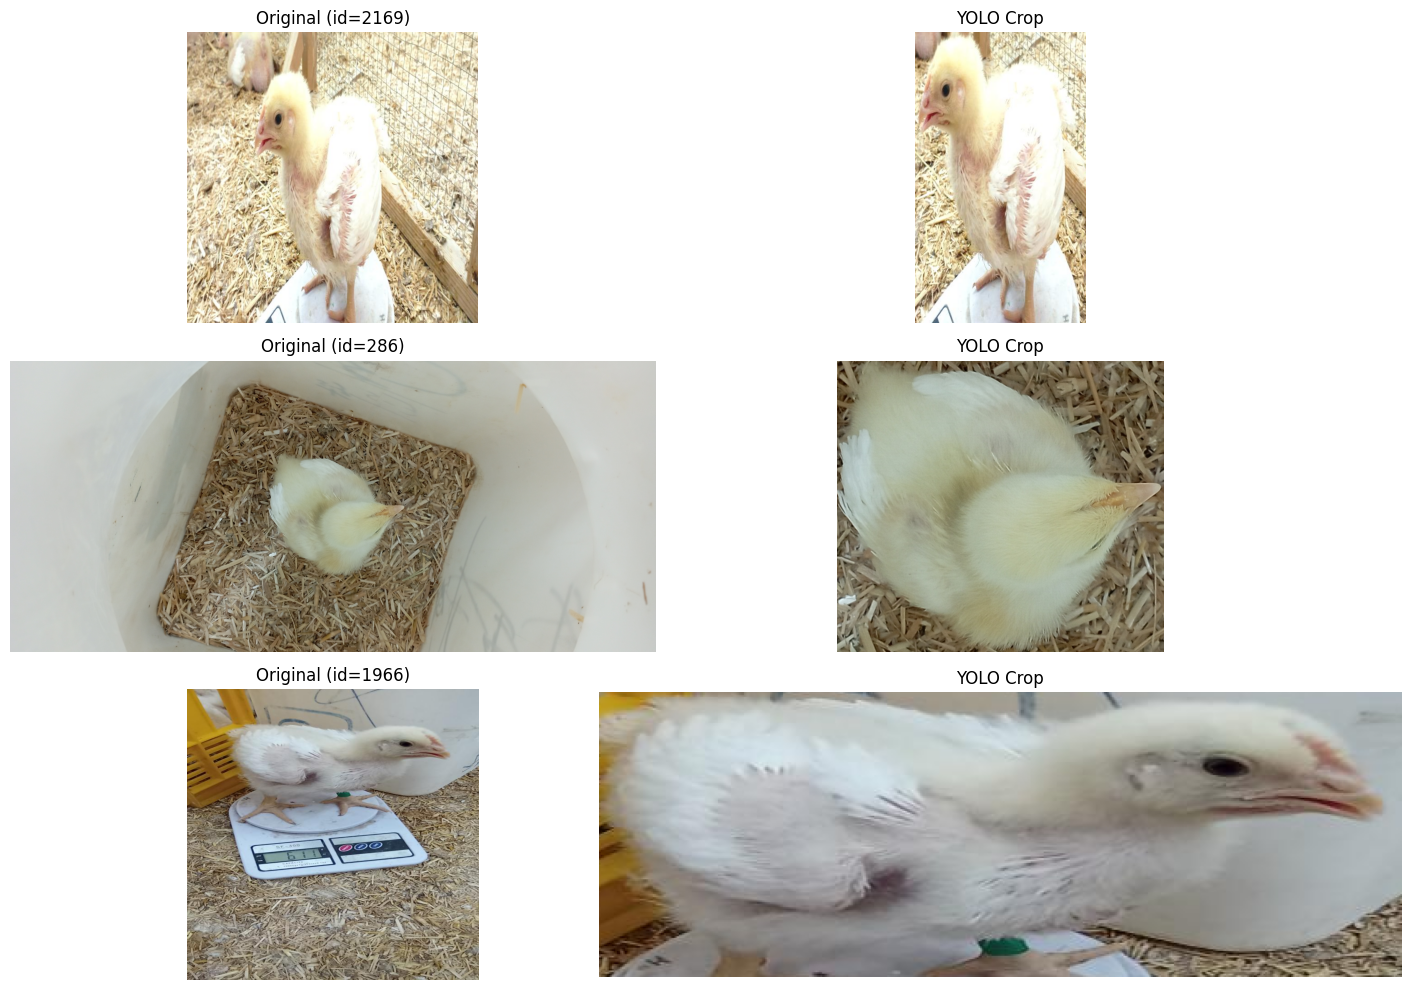

In [10]:
plt.figure(figsize=(15, 10))

for i in range(3):
    idx = random.randint(0, len(dataset["train"]) - 1)
    sample = dataset["train"][idx]
    
    img_np = np.array(sample["image"])
    cropped = yolo_crop(img_np, yolo)
    
    # Original
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(img_np)
    plt.title(f"Original (id={idx})")
    plt.axis("off")
    
    # Crop
    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(cropped)
    plt.title("YOLO Crop")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Data augmentation

In this notebook, the data augmentation strategy is slightly adjusted compared to previous experiments. While *Notebook 03* used a simpler set of transformations, and *Notebook 04* introduced more aggressive augmentations (e.g., random resized crops), here we adopt a more balanced approach.

Since images are already preprocessed using YOLO-based cropping, the input is cleaner and more focused on the target object. Therefore, we avoid strong spatial augmentations that could distort or remove relevant parts of the chicken, and instead apply moderate transformations (rotation, color jitter) to improve robustness while preserving the integrity of the object.

In [11]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.1,
        hue=0.03
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 3. Data Preparation for Training (PyTorch)

In this notebook, YOLO-based preprocessing is integrated into the dataset pipeline. Each image is first cropped around the detected chicken before applying transformations, ensuring that the model focuses on the relevant object instead of background information. The remaining pipeline is kept consistent with previous experiments for fair comparison.

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

In [13]:
class YoloCroppedPoultryDataset(Dataset):
    def __init__(self, hf_dataset, yolo, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.yolo = yolo
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        # Convert to numpy
        img_np = np.array(image)

        # YOLO crop
        img_np = yolo_crop(img_np, self.yolo)

        # Back to PIL for transforms
        image = Image.fromarray(img_np)

        if self.transform:
            image = self.transform(image)

        weight = (float(weight) - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

## 4. Train / Validation Split

The data split and normalization strategy remain unchanged from previous notebooks to ensure a fair comparison. Although images are now preprocessed using YOLO, the same train/validation division and target normalization are applied.

In [14]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Fix seed for reproducibility
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


In [15]:
train_weights = [sample["weight"] for sample in train_subset]

mean_weight = np.mean(train_weights)
std_weight = np.std(train_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 470.08
Std weight: 391.41


In [16]:
train_dataset = YoloCroppedPoultryDataset(
    train_subset,
    yolo=yolo,
    transform=train_transform, # With data augmentation
    mean=mean_weight,
    std=std_weight
)

val_dataset = YoloCroppedPoultryDataset(
    val_subset,
    yolo=yolo,
    transform=val_transform, # Without data augmentation
    mean=mean_weight,
    std=std_weight
)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## 5. Model

We use a pretrained ResNet18 and apply the same fine-tuning strategy as in *Notebook 03*, unfreezing only the last block (layer4). This ensures a fair comparison and allows us to isolate the effect of YOLO-based preprocessing.

In [18]:
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

# Load pretrained ResNet18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (layer4)
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

# Replace final layer for regression
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

# Move to device
device = torch.device("cpu")
model = model.to(device)

## 6. Training with Validation

We train the model using the same procedure as in *Notebook 03*.

In [19]:
import torch.optim as optim

# Loss
criterion = nn.MSELoss()

# ONLY the trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 30

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/30] - Train Loss: 0.4349 - Val Loss: 0.2925
Epoch [2/30] - Train Loss: 0.2438 - Val Loss: 0.3322
Epoch [3/30] - Train Loss: 0.1871 - Val Loss: 0.2087
Epoch [4/30] - Train Loss: 0.1531 - Val Loss: 0.2145
Epoch [5/30] - Train Loss: 0.1293 - Val Loss: 0.2066
Epoch [6/30] - Train Loss: 0.1174 - Val Loss: 0.1735
Epoch [7/30] - Train Loss: 0.1185 - Val Loss: 0.1752
Epoch [8/30] - Train Loss: 0.1086 - Val Loss: 0.1613
Epoch [9/30] - Train Loss: 0.0999 - Val Loss: 0.1405
Epoch [10/30] - Train Loss: 0.0863 - Val Loss: 0.1697
Epoch [11/30] - Train Loss: 0.0949 - Val Loss: 0.1455
Epoch [12/30] - Train Loss: 0.0820 - Val Loss: 0.1726
Epoch [13/30] - Train Loss: 0.0787 - Val Loss: 0.1613
Epoch [14/30] - Train Loss: 0.0792 - Val Loss: 0.1288
Epoch [15/30] - Train Loss: 0.0727 - Val Loss: 0.1638
Epoch [16/30] - Train Loss: 0.0671 - Val Loss: 0.1647
Epoch [17/30] - Train Loss: 0.0665 - Val Loss: 0.1277
Epoch [18/30] - Train Loss: 0.0596 - Val Loss: 0.1260
Epoch [19/30] - Train Loss: 0.0554 - 

### Evaluation (MAE + Relative Error)

We evaluate the model using Mean Absolute Error (MAE) in grams, as well as a **relative error metric to better reflect performance across different weight ranges**.

The relative error is computed as the absolute error divided by the true weight, providing a percentage-based interpretation of the model’s accuracy.

In [20]:
model.eval()

mae = 0.0
relative_error = 0.0

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        # MAE
        mae += torch.abs(preds - targets).sum().item()

        # Relative error
        relative_error += (torch.abs(preds - targets) / targets).sum().item()

mae /= len(val_dataset)
relative_error /= len(val_dataset)

print(f"Validation MAE: {mae:.2f} grams")
print(f"Mean Relative Error: {relative_error:.4f} ({relative_error*100:.2f}%)")

Validation MAE: 78.06 grams
Mean Relative Error: 0.2108 (21.08%)


The results obtained with YOLO-based preprocessing show an improvement compared to the previous configuration in *Notebook 04*, reducing both MAE and relative error. However, the performance is still notably worse than the baseline established in *Notebook 03*.

This suggests that, although object-centered cropping helps reduce some noise, the preprocessing may also remove relevant contextual information or introduce inconsistencies in the input, ultimately limiting the model’s ability to accurately estimate weight.

### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

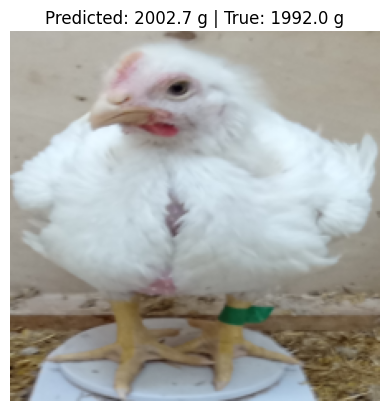

In [21]:
sample = val_dataset[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze().cpu()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

## 7. Error Analysis by Weight Range (Histogram)

To better understand the model's behavior, we analyze how prediction errors vary across different weight ranges.

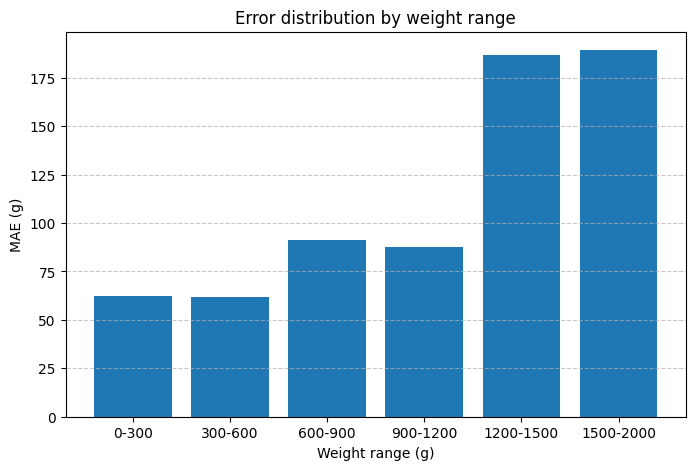

In [22]:
import numpy as np

model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

errors = np.abs(all_preds - all_targets)

# Define bins
bins = [0, 300, 600, 900, 1200, 1500, 2000]
bin_labels = []
mae_per_bin = []

for i in range(len(bins) - 1):
    mask = (all_targets >= bins[i]) & (all_targets < bins[i+1])
    
    if np.sum(mask) > 0:
        mae = np.mean(errors[mask])
        mae_per_bin.append(mae)
        bin_labels.append(f"{bins[i]}-{bins[i+1]}")

# Plot
plt.figure(figsize=(8,5))
plt.bar(bin_labels, mae_per_bin)

plt.xlabel("Weight range (g)")
plt.ylabel("MAE (g)")
plt.title("Error distribution by weight range")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Errors increase more sharply with weight compared to Notebook 03, especially above 1200g. YOLO-based cropping leads to consistently higher errors, suggesting that removing contextual information harms performance, particularly for larger chickens.

## 8. Model Saving

We save the trained model to reuse it later without retraining.

In [23]:
torch.save(model.state_dict(), "resnet18_weight_estimation_05_yolo.pth")

np.save("val_predictions.npy", all_preds)
np.save("val_targets.npy", all_targets)